## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors
Team list and credits
- Kabyan Pathak: Writing - review & editing
- Nicholas Chan: Conceptualization, Background research,
- Siyuan Zheng: Conceptualization, Data curation,
- Sophia Zhao: Methodology, Experimental investigation
- Yuntian Zhao: Project administration, Analysis, Software


# Research Question

What impact has the increase in isekai anime production had on the audiences reception over the past decade? How has the average rating of the genre been affected? How does episode count corelate with rating and viewership within isekai titles‘ length? Does the time of release (Winter/Spring/Summer/Fall) have any impact on the reception of said titles? What are the key features that determines an Isekai Anime's rating?

## Background and Prior Work


Over the last decade anime has become more mainstream and with it isekai has become one of its top produced genres. ”Isekai”, meaning another world in Japanese, refers to a story where the main protagonist is transported, trapped, or reborn into a fantasy world. 
While the genre has been around since the 1980’s, it wasn't until recently that the genre has really taken off. Just in 2024, the genre made up 15% of new release anime tv shows with 34 isekai being released. However with the rise of the genre, it 
has faced increasing criticism from audiences as they feel the genre is being overproduced and filled with unoriginal ideas. (1) 

Knowing this our group has decided to explore the truth behind how the audience really feels about the genre. By analyzing more than a decade of industry data and user reviews through MyAnimeList (MAL), we aim to determine whether the rapid growth 
in isekai production has contributed to a decline in average ratings or whether the genre has maintained its popularity. We also wish to see whether episode count or release season has any impact on overall audience rating. 

In reviewing previous analyses done on anime using data from MyAnimeList, we found that shows with more than 26 episodes seemed to be less popular than shorter series by about 33% (2). Another analysis done on the rise of isekai found that despite the 
increase in production of the genre isekai’s are still doing very well. Despite community consensus on there being too much isekai, the analysis viewership data shows that the genre has not yet hit the point of diminishing returns and was the second most 
popular in English speaking territories after action in 2024.(3) 

 Sources: 
1. [Anime Industry Overproduction & Isekai Report](https://screenrant.com/anime-industry-problems-overproduction-isekai-report/) 
2. [What Makes an Anime Popular? Statistical Analysis Using MAL Data](https://rpubs.com/SPIJ/714155) 
3. [The State of Isekai Anime](https://www.animenewsnetwork.com/feature/2025-01-22/the-state-of-isekai-anime/.219776) 


# Hypothesis


We hypothesize that we will see a decrease in the overall rating and viewership of the genre due to over saturation leading to lower quality productions and unoriginal repetitive plots. We think that we will start to see a trend of shorter series within the genre and higher quality/more popular isekai's being produced in the fall and winter. We believe that the most impactful features that determines an anime's rating is features related to its fan base.

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# # Setup code -- Run only once after cloning!!! 
# #
# # this code downloads the data from its source to the `data/00-raw/` directory
# # if the data hasn't updated you don't need to do this again!

# # if you don't already have these packages (you should!) uncomment this line
# # %pip install requests tqdm

# import sys
# sys.path.append('./modules') # this tells python where to look for modules to import

# import get_data # this is where we get the function we need to download data

# # replace the urls and filenames in this list with your actual datafiles
# # yes you can use Google drive share links or whatever
# # format is a list of dictionaries; 
# # each dict has keys of 
# #   'url' where the resource is located
# #   'filename' for the local filename where it will be stored 
# datafiles = [
#     { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
#     { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
# ]

# get_data.get_raw(datafiles,destination_directory='data/00-raw/')

In [3]:
# imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

### Dataset #1: MyAnimeList site info updated to 2026

This dataset is created from updating [kaggle dataset source](https://www.kaggle.com/datasets/neelagiriaditya/anime-dataset-jan-1917-to-oct-2025) with the most recent anime entries in 2026 using [this script](https://www.kaggle.com/code/rivuletnriver/mal-data-scraping) that essentially searches for all the animes listed using the official myanimelist api, comparing it with entries included in the existing kaggle dataset, and further extracted those that are missing in the existing dataset using jikan api (unofficial). 

The dataset includes many columns describing the information of the anime, and important ones for answering our research question are:
1. mal_id: anime id on myanimelist official website
2. title: english title of the anime
3. type: type of the work (there are multiple types of animes including Movie, Music, OVA, TV, Special, etc)
4. score: public rating of the anime
5. start_date: when the anime starts airing
6. synopsis: summary of the plot of the anime
7. rank, popularity, members, favorites: information that implies how successful an anime is besides the score
8. genres, themes: type of the plot of the anime
9. season: the season in which an anime is produced

#### Identity & Metadata:
    Variables: mal_id, title
    Definition: Unique identifiers for individual records
#### Production feature:
    Variables: type, start_date, season
    Definition: Metrics indicating the industry's output, scheduling strategies and so on
    By aggregating start_date, we can track publish count per year/season, to see detect the activity of industry.
#### Context:
    Variables: genres,themes,synopsis
    Definition: Qualitative features that define the nature, premise,and target demographic of the work.
    There variables allow for fair compraisons. For example, "isekai school" action series naturally have higher members than niche "Experimental" ones.
#### Outcomes & Market Performance
    Variables: score, rank, popularity, members, favorites
    Definition: Quantitative metrics used to meqasure the "Success" of an anime from both a critical and commerical perspective.
    Correlation: Investigating the relationship between score and members to further distinguish "hidden gemes" versus "overhyped" titles.
One of the problems with this dataset is that it contains a lot of missing values that can either be inferred from known information or needs to be further retrieved using jikan API. However, since it's drawn from the largest public anime site that exists, it provides valuable insights as to how we can answer our research question.

In [4]:
anime2026_df = pd.read_csv("data/00-raw/anime_extended_winter2026.csv")
print(anime2026_df.shape)
anime2026_df.head()

(29382, 29)


,mal_id,title,title_japanese,url,image_url,type,status,score,scored_by,start_date,end_date,synopsis,rank,popularity,members,favorites,genres,studios,themes,demographics,source,rating,episodes,season,year,producers,explicit_genres,licensors,streaming
0,59356,-Socket-,-socket-,https://myanimelist.net/anime/59356/-Socket-,https://cdn.myanimelist.net/images/anime/1043/...,Movie,Finished Airing,NaN,NaN,2010-01-01T00:00:00+00:00,NaN,A girl with a cord growing out of her back wan...,17086.0,22507,195,0,['Comedy'],[],[],[],Original,G - All Ages,1.0,NaN,NaN,['Nagoya Zokei University'],[],[],[]
1,56036,......,......,https://myanimelist.net/anime/56036/-,https://cdn.myanimelist.net/images/anime/1057/...,Music,Finished Airing,6.53,503.0,2023-06-11T00:00:00+00:00,NaN,Music video directed by obmolot for the song ....,NaN,15004,941,2,"['Horror', 'Supernatural']",['Flat Studio'],['Music'],[],Original,PG-13 - Teens 13 or older,1.0,NaN,NaN,[],[],[],[]
2,2928,.hack//G.U. Returner,.HACK//G.U. RETURNER,https://myanimelist.net/anime/2928/hack__GU_Re...,https://cdn.myanimelist.net/images/anime/1798/...,OVA,Finished Airing,6.65,9745.0,2007-01-18T00:00:00+00:00,NaN,The characters from previous .hack//G.U. Games...,6366.0,5056,22525,31,"['Adventure', 'Drama', 'Fantasy']",['Bee Train'],['Video Game'],[],Game,PG-13 - Teens 13 or older,1.0,NaN,NaN,"['Bandai Visual', 'CyberConnect2']",[],[],[]
3,3269,.hack//G.U. Trilogy,.hack//G.U. Trilogy,https://myanimelist.net/anime/3269/hack__GU_Tr...,https://cdn.myanimelist.net/images/anime/1566/...,Movie,Finished Airing,7.06,15373.0,2007-12-22T00:00:00+00:00,NaN,"Based on the CyberConnect2 HIT GAME, now will ...",4194.0,4215,34264,104,"['Action', 'Fantasy']",['CyberConnect2'],['Video Game'],[],Game,PG-13 - Teens 13 or older,1.0,NaN,NaN,['Bandai Visual'],[],"['Funimation', 'Bandai Entertainment']",[]
4,4469,.hack//G.U. Trilogy: Parody Mode,.hack//G.U. Trilogy,https://myanimelist.net/anime/4469/hack__GU_Tr...,https://cdn.myanimelist.net/images/anime/10/86...,Special,Finished Airing,6.35,4317.0,2008-03-25T00:00:00+00:00,NaN,A special bonus Parody Mode added to the extra...,8182.0,6696,11135,10,"['Comedy', 'Fantasy', 'Sci-Fi']",[],"['Parody', 'Video Game']",[],Game,PG-13 - Teens 13 or older,1.0,NaN,NaN,['Bandai Visual'],[],[],[]


In [5]:
anime2026_df.columns

Index(['mal_id', 'title', 'title_japanese', 'url', 'image_url', 'type',
       'status', 'score', 'scored_by', 'start_date', 'end_date', 'synopsis',
       'rank', 'popularity', 'members', 'favorites', 'genres', 'studios',
       'themes', 'demographics', 'source', 'rating', 'episodes', 'season',
       'year', 'producers', 'explicit_genres', 'licensors', 'streaming'],
      dtype='object')

### Manually input the season based on the start date for those missing

In [6]:
anime2026_df['season'].isna().sum()

23068

In [7]:
# end_date is not as helpful as there are too many missing
print(anime2026_df['start_date'].isna().sum())
print(anime2026_df['end_date'].isna().sum())

851
18075


In [8]:
anime2026_df['start_date'] = pd.to_datetime(anime2026_df['start_date'])
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring', 6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Fall', 10: 'Fall', 11: 'Fall'}
# season_map = {1: 'Winter', 2: 'Winter', 3: 'Winter', 4: 'Spring', 5: 'Spring', 6: 'Spring', 7: 'Summer', 8: 'Summer', 9: 'Summer', 10: 'Fall', 11: 'Fall', 12: 'Fall'}
anime2026_df['season_inferred'] =  anime2026_df['start_date'].dt.month.map(season_map)

anime2026_df['season_inferred']

0        Winter
1        Summer
2        Winter
3        Winter
4        Spring
          ...  
29377    Summer
29378    Winter
29379    Summer
29380    Summer
29381    Spring
Name: season_inferred, Length: 29382, dtype: object

In [9]:
# check for number of conflicts between inferred value and the original
real_season = anime2026_df['season'].str.lower()
inferred_season = anime2026_df['season_inferred'].str.lower()
conflicts = anime2026_df[(anime2026_df['season'].notna()) & (real_season != inferred_season)]
conflicts.shape[0]

43

In [10]:
# merge into season column
anime2026_df['season'] = anime2026_df['season'].str.capitalize()
anime2026_df['season'] = anime2026_df['season'].combine_first(anime2026_df['season_inferred'])
anime2026_df.drop(columns=['season_inferred'], inplace=True)
anime2026_df['season'].isna().sum()

851

In [11]:
# check if any of the rows missing season info is of genre isekai
nan_seasons = anime2026_df[anime2026_df['season'].isna()]
isekai_missing_season = nan_seasons[nan_seasons['themes'].astype(str).str.contains('Isekai', case=False)]
print(f"{len(isekai_missing_season)} Isekai misses season value")

30 Isekai misses season value


In [12]:
isekai_missing_season['status'].value_counts()

status
Not yet aired      29
Finished Airing     1
Name: count, dtype: int64

In [13]:
isekai_missing_season[isekai_missing_season['status'] == 'Finished Airing']

,mal_id,title,title_japanese,url,image_url,type,status,score,scored_by,start_date,end_date,synopsis,rank,popularity,members,favorites,genres,studios,themes,demographics,source,rating,episodes,season,year,producers,explicit_genres,licensors,streaming
6664,40244,Fushigi no Kuni no Alice Specials,ふしぎの国のアリス,https://myanimelist.net/anime/40244/Fushigi_no...,https://cdn.myanimelist.net/images/anime/1166/...,Special,Finished Airing,NaN,NaN,NaT,NaN,NaN,18695.0,19064,397,1,"['Adventure', 'Fantasy']",['Nippon Animation'],"['Anthropomorphic', 'Isekai']",['Kids'],Book,G - All Ages,2.0,NaN,NaN,[],[],[],[]


In [14]:
# filter out the 30 nan entries missing season value
anime2026_df = anime2026_df[~anime2026_df['season'].isna()]

### Limit the scope, include only isekai animes, and fill in missing values in important freature columns with jikan api

In [15]:
isekai_df = anime2026_df[anime2026_df['themes'].astype(str).str.contains('Isekai', case=False)].reset_index(drop = True)

In [16]:
import requests
import time
from tqdm import tqdm

ids_to_fix = isekai_df[isekai_df['score'].isna() | isekai_df['rank'].isna() | isekai_df['rating'].isna() | isekai_df['scored_by'].isna() | isekai_df['episodes'].isna()].index
print(f"total of {len(ids_to_fix)} rows")

for idx in tqdm(ids_to_fix, desc = "retrieving"):
    mal_id = isekai_df.at[idx, 'mal_id']
    try:
        url = f"https://api.jikan.moe/v4/anime/{mal_id}"
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json().get('data', {})
            isekai_df.at[idx, 'score'] = data.get('score')
            isekai_df.at[idx, 'rank'] = data.get('rank')
            isekai_df.at[idx, 'rating'] = data.get('rating')
            isekai_df.at[idx, 'scored_by'] = data.get('scored_by')
            isekai_df.at[idx, 'episodes'] = data.get('episodes')
            
        else:
            print(f"ID {mal_id}: {response.status_code})")
            
        time.sleep(1.2)

    except Exception as e:
        print(f"error on ID {mal_id}: {e}")

print('Done')

total of 56 rows


retrieving: 100%|██████████| 56/56 [01:40<00:00,  1.79s/it]

Done


In [17]:
print(f"now we have {isekai_df[isekai_df['score'].isna()].shape[0]} entries missing a score")

now we have 19 entries missing a score


The ones that are missing is either not aired yet or doesn't have a score on the official site, so we discard them'

In [18]:
# Discard the nan's in score and further filter by fan base
real_isekai = isekai_df[isekai_df['score'].notna() & ((isekai_df['scored_by'] > 1000) | (isekai_df['members'] > 1000))].reset_index(drop = True)
real_isekai.shape

(387, 29)

good enough Good enough size to do T-Tests / ANOVA to see if the difference between Winter, Fall and other two seasons' scores is statistically significant

In [19]:
real_isekai['inferred_year'] = real_isekai['start_date'].dt.year
print(real_isekai[real_isekai['inferred_year'] != real_isekai['year']].shape[0])
# so it's only the 145 that are missing the year value, we just fill it in
real_isekai['year'] = real_isekai['inferred_year'] 
real_isekai = real_isekai.drop('inferred_year', axis = 1)
list_cols = ['producers', 'licensors', 'streaming', 'demographics']
for col in list_cols:
    real_isekai[col] = real_isekai[col].apply(lambda x: [] if pd.isna(x) else x)
real_isekai = real_isekai.fillna(value={'rank' : 0,})
real_isekai = real_isekai.drop(['end_date', 'explicit_genres'], axis = 1)
mask_syn = real_isekai['synopsis'].isna()
real_isekai.loc[mask_syn, 'synopsis'] = ("follows a Japanese high schooler reincarnated as 8-year-old Princess Pride Royal Ivy, "
                                         "the destined evil final boss of an otome game. She uses her cheat abilities and "
                                         "game knowledge to prevent tragedies and save her kingdom")
mask_title = real_isekai['title_japanese'].isna()
real_isekai.loc[mask_title, 'title_japanese'] = '劇場版 転生したらスライムだった件 紅蓮の絆編'
                                           

145


In [20]:
finalized_isekai = real_isekai[['mal_id', 'title', 'type', 'status', 'score', 'start_date', 'rank', 'popularity', 'members','favorites', 'genres', 'themes', 'episodes', 'season', 'year']]
finalized_isekai = finalized_isekai[finalized_isekai['type'] == 'TV']
finalized_isekai["season_length"] = pd.cut(
    finalized_isekai["episodes"],
    bins=[0, 13, 26, float("inf")],
    labels=["Short", "Medium", "Long"]
)
finalized_isekai

,mal_id,title,type,status,score,start_date,rank,popularity,members,favorites,genres,themes,episodes,season,year,season_length
0,58985,0-saiji Start Dash Monogatari,TV,Finished Airing,5.43,2024-07-07 00:00:00+00:00,12703.0,6424,12263,24,"['Adventure', 'Fantasy']","['Isekai', 'Reincarnation']",12.0,Summer,2024,Short
1,60425,0-saiji Start Dash Monogatari Season 2,TV,Finished Airing,5.63,2025-01-05 00:00:00+00:00,12053.0,9660,4376,10,"['Adventure', 'Fantasy']","['Isekai', 'Reincarnation']",12.0,Winter,2025,Short
2,41380,100-man no Inochi no Ue ni Ore wa Tatteiru,TV,Finished Airing,6.52,2020-10-02 00:00:00+00:00,7107.0,826,324016,701,"['Action', 'Adventure', 'Drama', 'Fantasy']",['Isekai'],12.0,Fall,2020,Short
3,44881,100-man no Inochi no Ue ni Ore wa Tatteiru 2nd...,TV,Finished Airing,6.79,2021-07-10 00:00:00+00:00,5509.0,1453,182088,640,"['Action', 'Adventure', 'Drama', 'Fantasy']",['Isekai'],12.0,Summer,2021,Short
5,306,Abenobashi Mahou☆Shoutengai,TV,Finished Airing,7.21,2002-04-04 00:00:00+00:00,3376.0,2364,96358,380,"['Award Winning', 'Comedy', 'Fantasy', 'Ecchi']","['Isekai', 'Parody']",13.0,Spring,2002,Short
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,58502,Zenshuu.,TV,Finished Airing,7.58,2025-01-05 00:00:00+00:00,1705.0,1706,149997,865,"['Action', 'Fantasy']",['Isekai'],12.0,Winter,2025,Short
380,1195,Zero no Tsukaima,TV,Finished Airing,7.20,2006-07-03 00:00:00+00:00,3495.0,243,855507,8120,"['Action', 'Adventure', 'Comedy', 'Fantasy', '...","['Harem', 'Isekai', 'School']",13.0,Summer,2006,Short
381,11319,Zero no Tsukaima F,TV,Finished Airing,7.41,2012-01-07 00:00:00+00:00,2423.0,576,439736,1228,"['Action', 'Adventure', 'Comedy', 'Fantasy', '...","['Harem', 'Isekai', 'School']",12.0,Winter,2012,Short
382,1840,Zero no Tsukaima: Futatsuki no Kishi,TV,Finished Airing,7.39,2007-07-09 00:00:00+00:00,2490.0,465,522752,1290,"['Action', 'Adventure', 'Comedy', 'Fantasy', '...","['Harem', 'Isekai', 'School']",12.0,Summer,2007,Short


In [21]:
# # save
# real_isekai.to_csv(r'data/02-processed/isekai_clean.csv', index = False)

# finalized_isekai.to_csv(r'data/02-processed/isekai_final.csv', index = False)

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [22]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Dependencies and Load data

In [23]:
!pip install catboost -q
!pip install wordcloud -q

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re 

from catboost import Pool, CatBoostRegressor

from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import pearsonr, spearmanr

from wordcloud import WordCloud, STOPWORDS
import nltk
from nltk.corpus import stopwords

In [25]:
df = pd.read_csv('data/02-processed/isekai_final.csv')

#### Section 1 of EDA - Analyzing Growth of Isekai

To understand our data in relation to our question first lets take a look at first the growth of the genre.

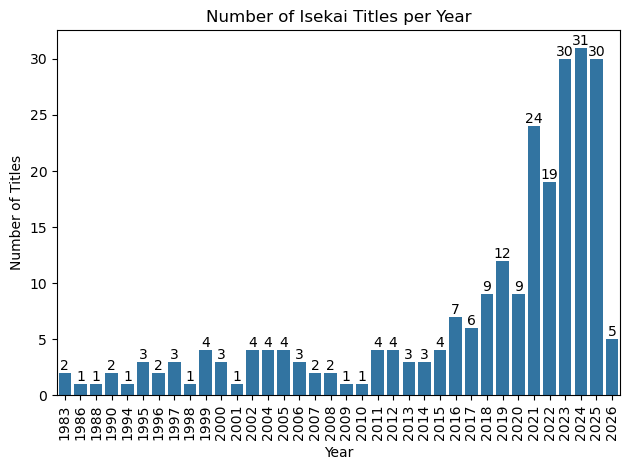

In [26]:
#find the number of animes produced each year and plots them on bar graph
df['start_date'] = pd.to_datetime(df['start_date'])
titles_per_year = df.groupby(df['year']).size()
ax = sns.barplot(
    x=titles_per_year.index,
    y=titles_per_year.values
)
plt.title("Number of Isekai Titles per Year")
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=90)
ax.bar_label(ax.containers[0])

plt.tight_layout()
plt.show()

In [27]:
#calculates what percentage of animes released that year were Isekai
anime_recent = anime2026_df[anime2026_df['year'] >= 2016]
isekai_recent = df[df['year'] >= 2016]  
total_per_year = anime_recent.groupby('year').size()
isekai_per_year = isekai_recent.groupby('year').size()
isekai_percentage = (isekai_per_year / total_per_year) * 100
isekai_percentage = isekai_percentage.fillna(0)
isekai_percent_df = isekai_percentage
isekai_percent_df

year
2016     2.473498
2017     2.135231
2018     3.202847
2019     5.240175
2020     4.090909
2021     9.795918
2022     8.050847
2023    10.526316
2024    10.915493
2025    10.309278
2026     5.882353
dtype: float64

Here we can see that the Isekai genre began to take off somewhere between 2018-2020 and production really soring after 2020, accounting for about 10% of all animes released that year. The 2026 data is incomplete since the year is not over yet so lets ignore that for now. Now lets take a look at the average ratings across each year and see if the increase in production has impacted the ratings at all.

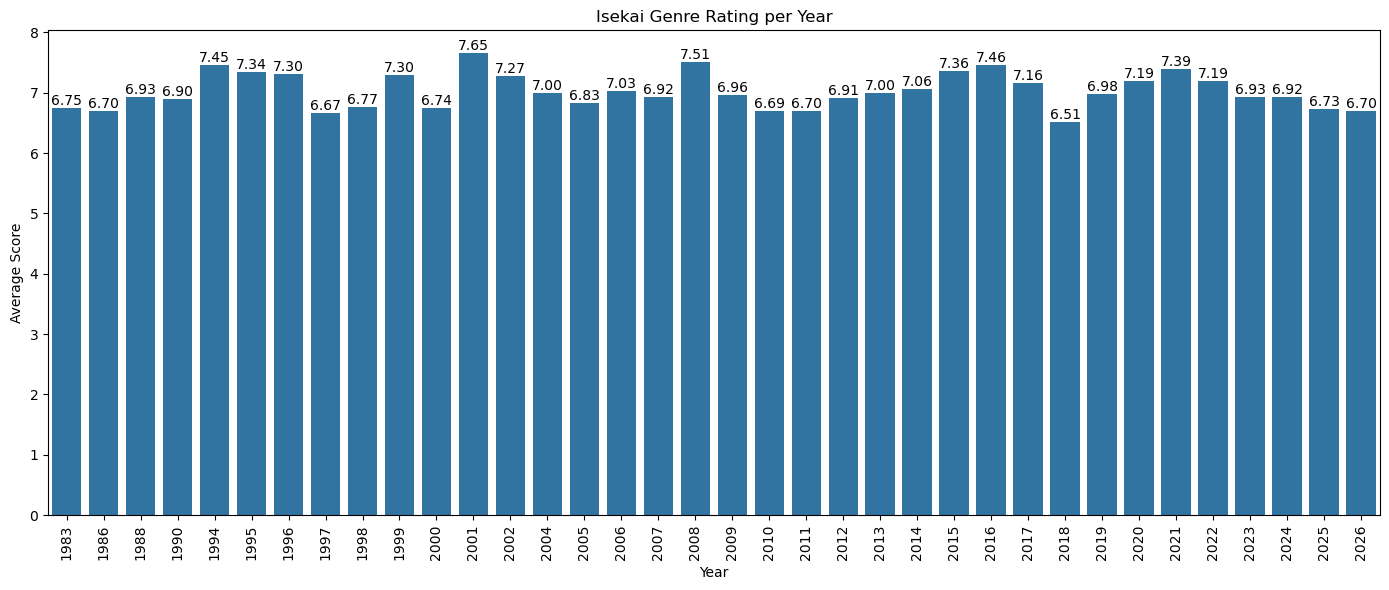

In [28]:
#calculates average ratings each year and plots bar chart
ratings_per_year = df.groupby(df['year'])['score'].mean()
plt.figure(figsize=(14,6))
ax = ax = sns.barplot(
    x=ratings_per_year.index,
    y=ratings_per_year.values
)
plt.title("Isekai Genre Rating per Year")
plt.xlabel('Year')
plt.ylabel('Average Score')
plt.xticks(rotation=90)
ax.bar_label(ax.containers[0], fmt="%.2f")

plt.tight_layout()
plt.show()

Here we can see that the average score for the genre hovers somewhere between 6-7. Now lets test to see if there is actually any correlation between production amount and average score.

In [29]:
#tests if there is a significance between number of titles produced and yearly average score
from scipy.stats import pearsonr
yearly_df = pd.DataFrame({
    'titles': titles_per_year,
    'avg_score': ratings_per_year})
corr, p_value = pearsonr(yearly_df['titles'], yearly_df['avg_score'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.04634750793415671
P-value: 0.7883798006918264


We get a p-val of 0.789 which means that the data does not support the idea that more production inheretly leads to lower average scores of the genre. Perhaps this means that public reception of Isekai is remaining stable and is not decreasing despite online communities opinions on the genre. People are still engaging in the genre titles regardless of how many are produced each year showing that people are still interested in this genre.

Next we want to test if episode count has any correlation with the score a title receives. Lets take a look and plot the mean values based on season_length.

season_length
Long      7.098077
Medium    7.358182
Short     6.957919
Name: score, dtype: float64


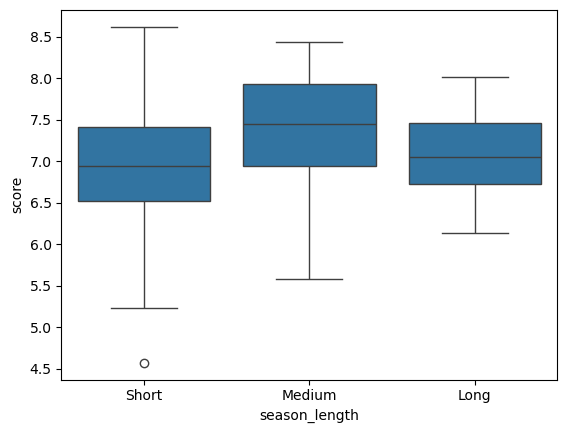

In [30]:
#calculate and plot the average rating based on season_length
season_score = df.groupby('season_length')['score'].mean()
print(season_score)

sns.boxplot(data=df, x='season_length', y='score')
plt.show()

In [31]:
model = smf.ols('score ~ C(season_length)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                      sum_sq     df        F    PR(>F)
C(season_length)    3.402730    2.0  3.79538  0.023824
Residual          108.481978  242.0      NaN       NaN


Running an ANOVA test on the scores based on season length, we see that there is a statistical significance between them, but we don't know between which groups, so lets run a post-hoc test to find out.

In [32]:
tukey = pairwise_tukeyhsd(df['score'], df['season_length'])
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  Long Medium   0.2601 0.3739 -0.1973  0.7175  False
  Long  Short  -0.1402 0.5755 -0.4696  0.1893  False
Medium  Short  -0.4003 0.0226 -0.7552 -0.0453   True
----------------------------------------------------


Our results show us that medium length season scored statistically lower than short length seasons with a mean diff = -0.4002 and p = 0.0227. Short seasons perform better than medium length seasons but perform similarly to long length seasons. 

Now lets answer the question of whether episode count affects viewership.

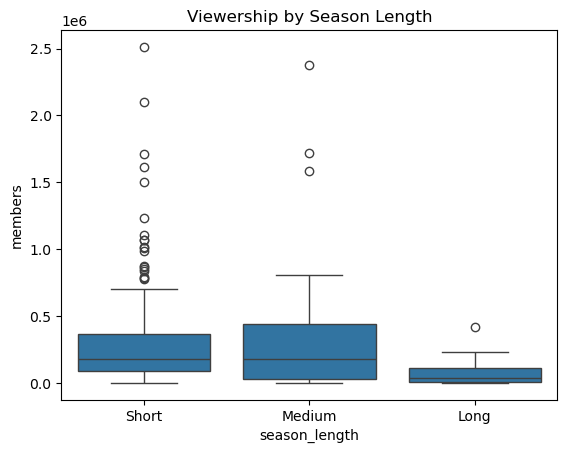

Correlation: SignificanceResult(statistic=-0.2080305857947513, pvalue=0.0010549404651566706)
Correlation: PearsonRResult(statistic=-0.13912835185133612, pvalue=0.029468208101091537)


In [33]:
sns.boxplot(data=df, x='season_length', y='members')
plt.title("Viewership by Season Length")
plt.show()
print("Correlation:", spearmanr(df['episodes'], df['members']))
print("Correlation:", pearsonr(df['episodes'], df['members']))

Our results show a weak relationship between season_length and members with titles with more episodes getting slightly less views than shorter seasons.

Next we will check if seasonal release time has any affect on the popularity of a title based on its members and score.

Titles per season: 
season
Fall      58
Spring    70
Summer    57
Winter    60
dtype: int64

Average rating per season: 
season
Fall      7.065517
Spring    7.015857
Summer    6.908772
Winter    7.040500
Name: score, dtype: float64


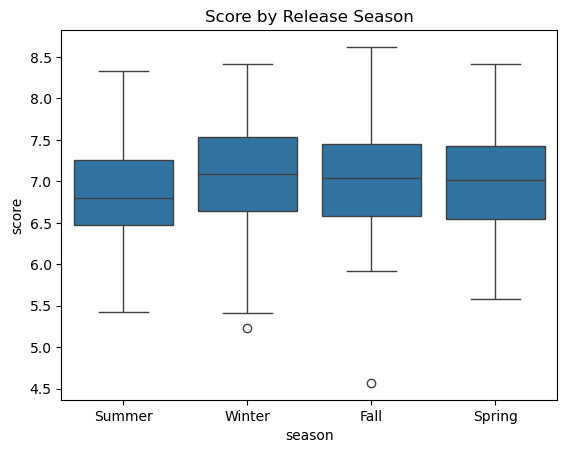

In [34]:
release_per_season = df.groupby('season').size()
rating_per_season = df.groupby('season')['score'].mean()
print(f'Titles per season: \n{release_per_season}\n')
print(f'Average rating per season: \n{rating_per_season}')
sns.boxplot(data=df, x='season', y='score')
plt.title("Score by Release Season")
plt.show()

Here we can see that the average ratings per season are all rougly the same with Spring being the time when most Isekai are released followed by Winter. Lets now run ANOVA to see if there is any statistical difference between them.

In [35]:
model = smf.ols('score ~ C(season)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(f'{anova_table}\n')
print(pairwise_tukeyhsd(df['score'], df['season']))

               sum_sq     df       F   PR(>F)
C(season)    0.820676    3.0  0.5936  0.61975
Residual   111.064032  241.0     NaN      NaN

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Fall Spring  -0.0497 0.9764 -0.3615 0.2622  False
  Fall Summer  -0.1567 0.6033 -0.4843 0.1708  False
  Fall Winter   -0.025 0.9972 -0.3484 0.2984  False
Spring Summer  -0.1071 0.8131 -0.4204 0.2062  False
Spring Winter   0.0246 0.9969 -0.2843 0.3336  False
Summer Winter   0.1317 0.7207 -0.1931 0.4566  False
---------------------------------------------------


This shows us that there is no statistical difference between the ratings received between different seasons. This means that season of release does not influence audience reception and is not a predictor of rating. Now lets test to see if one season tends to get more viewership than the others

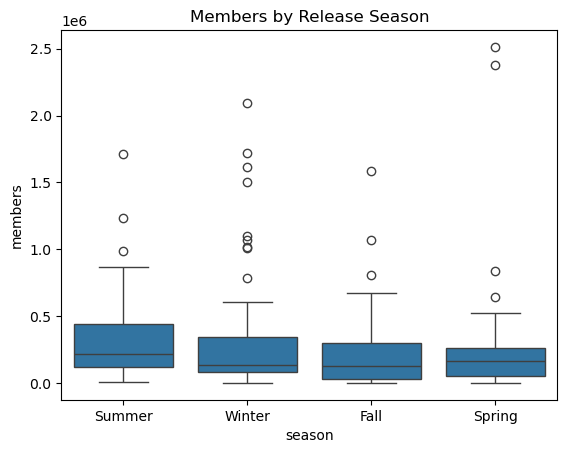

season
Fall      218989.000000
Spring    255265.242857
Summer    335774.912281
Winter    342577.500000
Name: members, dtype: float64

In [36]:
#calculates and plots avg views per season
sns.boxplot(data=df, x='season', y='members')
plt.title("Members by Release Season")
plt.show()

df.groupby('season')['members'].mean()

From this we see that Winter tends to attract the most views followed by Summer while Fall and Spring are on the lower end.  

Overall our results show that the increase in Isekai production has not led to a decline in overall rating of the genre and is still being well received by viewers. Titles with medium length seasons tend to receive slightly worse ratings compared to short or long seasons. Seasonal release times like Summer and Winter tend to attract more viewers but it has no affect on how well the titles are rated.

#### Section 2 of EDA ---- Identify key words and features in Isekai Animes

Investigating the most common and important words in isekai anime synopsis, along with a rating prediction that searches for the most important feature that influences rating additional to a linear correlation test

In [37]:
#prepare stopwords
stop_words = set(stopwords.words('english'))
stop_words.update (['another','become','one','two','first','new','world','anime'])


In [38]:
#preprocessing text function
def clean_text(text):
    if not isinstance(text,str) : return ""
    tokens = text.lower().split()
    clean_tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return " ".join (clean_tokens)

In [39]:
real_isekai['clean_synopsis'] = real_isekai['synopsis'].apply(clean_text)

In [40]:
high_score_text = "".join(real_isekai[real_isekai['score'] > 7.5] ['clean_synopsis'])
low_score_text = "".join(real_isekai[real_isekai['score'] < 6]['clean_synopsis'])

In [41]:
stop_words_list = list(set(stopwords.words('english')))

tfidf_vec = TfidfVectorizer(stop_words=stop_words_list, max_df=0.8, min_df=2, ngram_range=(1, 2))

corpus = real_isekai['clean_synopsis'].fillna("").tolist()
tfidf_matrix = tfidf_vec.fit_transform(corpus)

weights = tfidf_matrix.sum(axis=0).A1
words = tfidf_vec.get_feature_names_out()
word_weights = dict(zip(words, weights))

#### Generate WordClouds
    if 'score' > 7.5, we rate it as high_score
    if 'score' < 6.0, we rate it as low_score

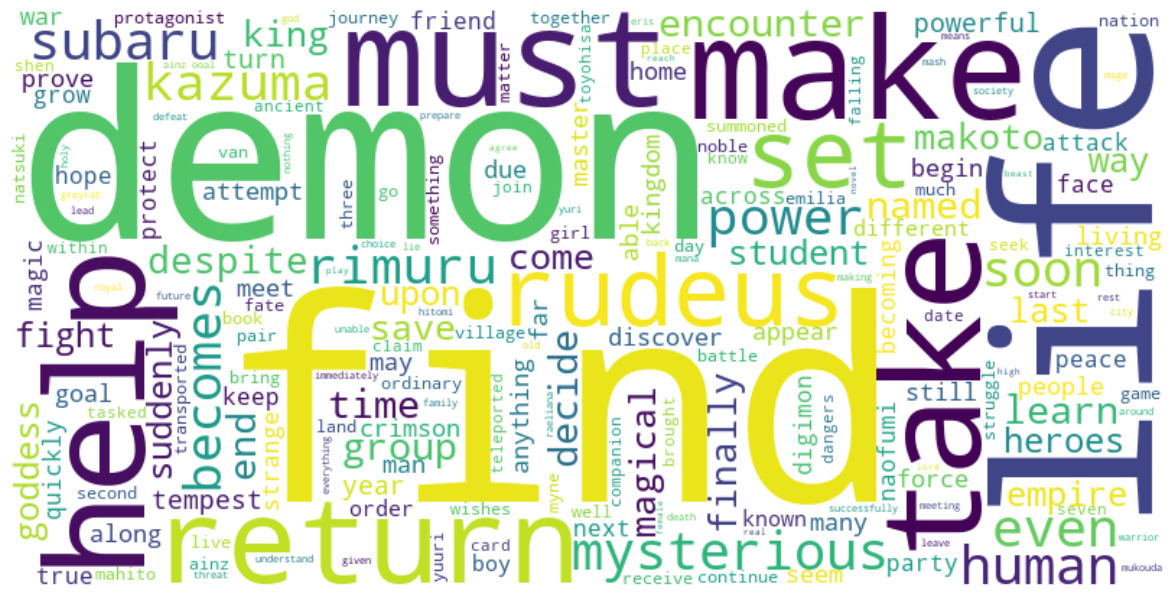

In [42]:
wc = WordCloud(width = 800, height=400,background_color='white').generate(high_score_text)
plt.figure(figsize=(15, 7.5))
plt.imshow(wc, interpolation='bilinear') 
plt.axis('off') 
plt.show() 

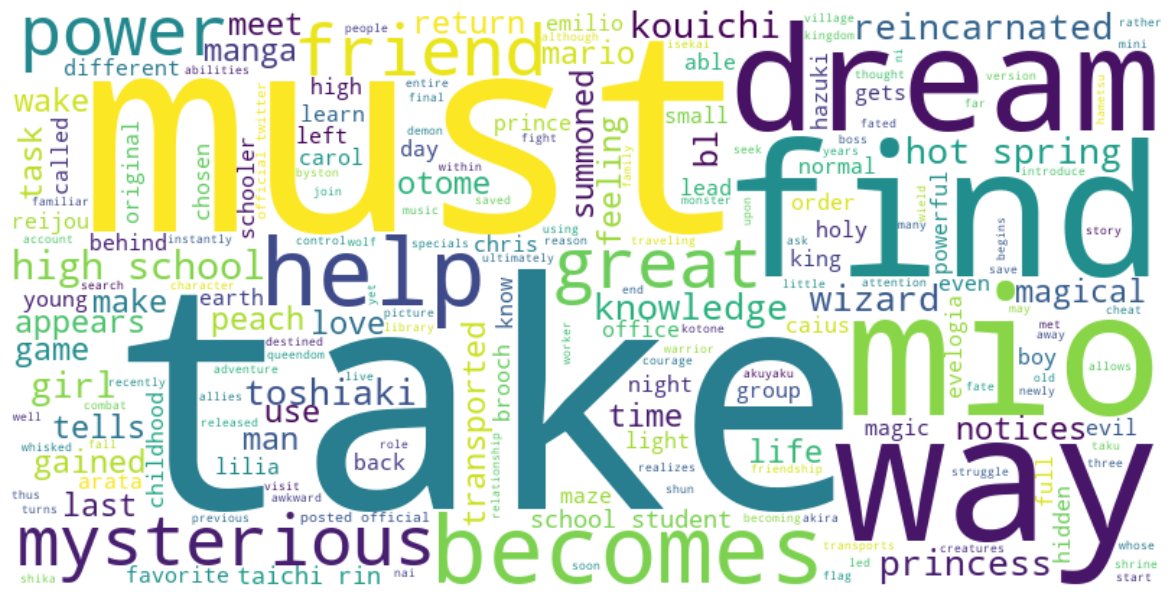

In [43]:
#for lower scored series
wc = WordCloud(width = 800, height=400,background_color='white').generate(low_score_text)
plt.figure(figsize=(15, 7.5))
plt.imshow(wc, interpolation='bilinear') 
plt.axis('off') 
plt.show() 

By generating two different wordclouds on two different sets, we can see high score titles focus on 'growth & connection', for example, "become","help","group","encounter", but for lower scored titles, they are too much focusing on patagonists shaping， and dominated with generic isekai settings like "princess","king", not a specific person like "rudeus"

Run one-way anova

In [44]:
df_clean = real_isekai.dropna(subset=['score', 'season']).copy()
anova_result = sm.stats.anova_oneway(data=df_clean['score'], groups=df_clean['season'])
print(anova_result)

statistic = 0.119336083627897
pvalue = 0.9486645740655474
df = (3.0, 209.5274999272278)
df_num = 3.0
df_denom = 209.5274999272278
nobs_t = 387.0
n_groups = 4
means = [6.91351648 6.89176471 6.91324074 6.95360465]
nobs = [ 91. 102. 108.  86.]
vars_ = [0.5861075  0.49011765 0.55779033 0.51586097]
use_var = unequal
welch_correction = True
tuple = (0.119336083627897, 0.9486645740655474)


the p-value is significantly larger than 0.05, the average score is also very close between seasons.
As we wrote in data

#### Train a catboost regressor for rating prediction based on tf-idf synopsis embeddings + other features to see what really matters for isekai anime rating

In [45]:
# pull + clean synopsis 
df_clean = pd.read_csv('data/02-processed/isekai_clean.csv')
df = df.merge(df_clean[df_clean['type'] == 'TV'][['mal_id', 'synopsis']], how  = 'left', on = 'mal_id')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text

df['synopsis'] = df['synopsis'].apply(lambda x: clean_text(x))

# get embeddings
tfidf = TfidfVectorizer(stop_words='english', max_features=3000, min_df=2)
tfidf_matrix = tfidf.fit_transform(df['synopsis'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f"tfidf_{c}" for c in tfidf.get_feature_names_out()], index=df.index) # add renaming so it doesn't conflict with our existing col names
tfidf_df

tfidf_10  tfidf_12  tfidf_15  tfidf_16  tfidf_17  tfidf_20  tfidf_25  \
0         0.0   0.00000       0.0       0.0       0.0       0.0       0.0   
1         0.0   0.00000       0.0       0.0       0.0       0.0       0.0   
2         0.0   0.00000       0.0       0.0       0.0       0.0       0.0   
3         0.0   0.00000       0.0       0.0       0.0       0.0       0.0   
4         0.0   0.15298       0.0       0.0       0.0       0.0       0.0   
..        ...       ...       ...       ...       ...       ...       ...   
240       0.0   0.00000       0.0       0.0       0.0       0.0       0.0   
241       0.0   0.00000       0.0       0.0       0.0       0.0       0.0   
242       0.0   0.00000       0.0       0.0       0.0       0.0       0.0   
243       0.0   0.00000       0.0       0.0       0.0       0.0       0.0   
244       0.0   0.00000       0.0       0.0       0.0       0.0       0.0   

     tfidf_30  tfidf_300  tfidf_34  tfidf_99  tfidf_abandoned  \
0    0.000000        0.0       0.0       0.0              0.0   
1    0.000000        0.0       0.0       0.0              0.0   
2    0.126562        0.0       0.0       0.0              0.0   
3    0.000000        0.0       0.0       0.0              0.0   
4    0.000000        0.0       0.0       0.0              0.0   
..        ...        ...       ...       ...              ...   
240  0.000000        0.0       0.0       0.0              0.0   
241  0.000000        0.0       0.0       0.0              0.0   
242  0.000000        0.0       0.0       0.0              0.0   
243  0.000000        0.0       0.0       0.0              0.0   
244  0.000000        0.0       0.0       0.0              0.0   

     tfidf_abilities  tfidf_ability  tfidf_able  tfidf_abruptly  \
0           0.000000            0.0         0.0             0.0   
1           0.000000            0.0         0.0             0.0   
2           0.000000            0.0         0.0             0.0   
3           0.000000            0.0         0.0             0.0   
4           0.000000            0.0         0.0             0.0   
..               ...            ...         ...             ...   
240         0.000000            0.0         0.0             0.0   
241         0.000000            0.0         0.0             0.0   
242         0.000000            0.0         0.0             0.0   
243         0.079572            0.0         0.0             0.0   
244         0.000000            0.0         0.0             0.0   

     tfidf_absolute  tfidf_absorbed  tfidf_absorbing  tfidf_abuse  \
0               0.0        0.000000              0.0          0.0   
1               0.0        0.000000              0.0          0.0   
2               0.0        0.000000              0.0          0.0   
3               0.0        0.000000              0.0          0.0   
4               0.0        0.000000              0.0          0.0   
..              ...             ...              ...          ...   
240             0.0        0.000000              0.0          0.0   
241             0.0        0.100197              0.0          0.0   
242             0.0        0.000000              0.0          0.0   
243             0.0        0.000000              0.0          0.0   
244             0.0        0.000000              0.0          0.0   

     tfidf_abused  tfidf_abyss  tfidf_academy  tfidf_accept  tfidf_accepting  \
0             0.0          0.0       0.000000           0.0              0.0   
1             0.0          0.0       0.000000           0.0              0.0   
2             0.0          0.0       0.000000           0.0              0.0   
3             0.0          0.0       0.000000           0.0              0.0   
4             0.0          0.0       0.000000           0.0              0.0   
..            ...          ...            ...           ...              ...   
240           0.0          0.0       0.000000           0.0              0.0   
241           0.0        

In [46]:
# process those two cols with list of entries
def parse_list_column(s):
    s = s.strip("[]")
    items = s.split(",")
    items = [item.strip().strip("'\"") for item in items if item.strip().strip("'\"")]
    return items

df['genres_list'] = df['genres'].apply(parse_list_column)
df['themes_list'] = df['themes'].apply(parse_list_column)

mlb_genres = MultiLabelBinarizer()
genres_encoded = mlb_genres.fit_transform(df['genres_list'])
mlb_themes = MultiLabelBinarizer()
themes_encoded = mlb_themes.fit_transform(df['themes_list'])

genres_df = pd.DataFrame(genres_encoded, columns=[f"genre_{c}" for c in mlb_genres.classes_], index=df.index)
themes_df = pd.DataFrame(themes_encoded, columns=[f"theme_{c}" for c in mlb_themes.classes_], index=df.index)

# prepare input and target
cat_cols = ['type', 'status', 'season', 'season_length']
num_cols = ['popularity', 'members', 'favorites', 'episodes', 'year'] # 'rank', using rank is unfair for the purpose, as it directly correlates with the rating
target_col = 'score'

cat_df = df[cat_cols + num_cols]
X_final = pd.concat([cat_df, tfidf_df, genres_df, themes_df], axis=1)
y_final = df[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(X_final, y_final, test_size=0.2, random_state = 42)
X_eval, X_test, y_eval, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state = 42)

In [47]:
train_pool = Pool(data = X_train, label = y_train, cat_features = cat_cols)
eval_pool = Pool(data = X_eval, label = y_eval, cat_features = cat_cols)
test_pool = Pool(data = X_test, label = y_test, cat_features = cat_cols)

In [48]:
model = CatBoostRegressor(iterations = 500, learning_rate = 0.05, depth = 7, verbose = 50, allow_writing_files=False)
model.fit(train_pool, eval_set = eval_pool)

0:	learn: 0.6632667	test: 0.7840738	best: 0.7840738 (0)	total: 77.9ms	remaining: 38.9s
50:	learn: 0.4015004	test: 0.7036939	best: 0.7036939 (50)	total: 1.01s	remaining: 8.92s
100:	learn: 0.3124793	test: 0.6915302	best: 0.6889209 (74)	total: 1.95s	remaining: 7.69s
150:	learn: 0.2248010	test: 0.6857876	best: 0.6836240 (141)	total: 2.84s	remaining: 6.56s
200:	learn: 0.1625972	test: 0.6777173	best: 0.6772631 (195)	total: 3.75s	remaining: 5.58s
250:	learn: 0.1180926	test: 0.6733480	best: 0.6733480 (250)	total: 4.71s	remaining: 4.67s
300:	learn: 0.0896472	test: 0.6714265	best: 0.6714265 (300)	total: 5.59s	remaining: 3.69s
350:	learn: 0.0692621	test: 0.6703693	best: 0.6700670 (335)	total: 6.46s	remaining: 2.74s
400:	learn: 0.0561158	test: 0.6704398	best: 0.6699314 (392)	total: 7.38s	remaining: 1.82s
450:	learn: 0.0457382	test: 0.6702888	best: 0.6699314 (392)	total: 8.29s	remaining: 901ms
499:	learn: 0.0379075	test: 0.6695632	best: 0.6694861 (497)	total: 9.16s	remaining: 0us

bestTest = 0.6694

CatBoostRegressor(allow_writing_files=False, depth=7, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=50)

In [49]:
# some metrics
y_pred = model.predict(test_pool)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"metrics on test set --> rmse: {rmse:.2f}, mae: {mae:.2f}, r2: {r2:.2f}")


metrics on test set --> rmse: 0.45, mae: 0.36, r2: 0.35


Despite the low metrics due to limited data size, we can still infer the most decisve features for further downstream analysis

In [50]:
# find the most decisive features
importance = model.get_feature_importance(train_pool)
features = X_train.columns
feat_df = pd.DataFrame({'feature': features, 'importance': importance}).sort_values(by = 'importance', ascending = False)

In [51]:
feat_df[:10]

,feature,importance
6,favorites,33.309257
5,members,7.960494
4,popularity,6.818542
2251,tfidf_world,6.036289
2307,theme_Harem,5.655089
8,year,1.969865
1247,tfidf_mal,1.331390
1704,tfidf_rewrite,1.303405
1932,tfidf_students,1.264581
1233,tfidf_magic,1.132650


#### Construct a heatmap to show the linear relationship between rating and the top 10 features gained from the catboost model prediction task

<Axes: >

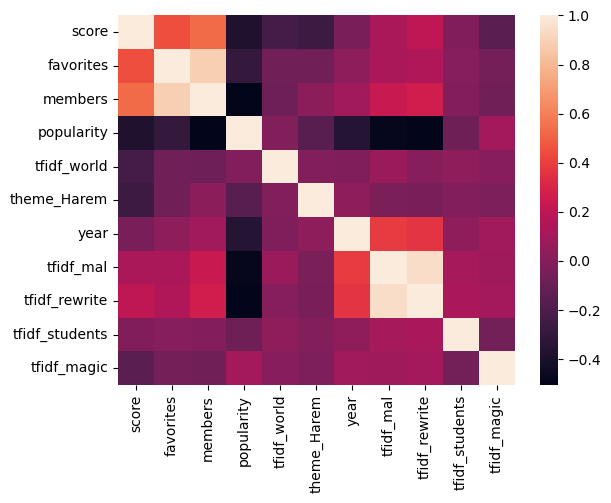

In [52]:
# heatmap of pearson correlation coefficients
sns.heatmap(pd.concat([df[['score']], X_final.loc[:, feat_df[:10]['feature'].values]], axis = 1).corr())

So afterall what's important for Isekai anime's rating is fan base. Interestingly, popularity seems to have a strong negative relationship with the rating. Some key words that contributes the most are 'world', 'Harem', 'mal', 'rewrite', 'students', and 'magic', which are relatively common in Isekai anime themes. 

## Ethics 

Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.
  
Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

>  Our data is from Kaggle which is a public web scrapped dataset of MAL users. While individuals are not informed about the use of their data we are looking at average/overall ratings rather than information on individual profiles. 

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
>  Our data relies on MAL ratings which in itself could be biased. It does not represent the whole community and may not proportionally represent anime fans of different regions. 

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

>  In our dataset we would not be using any individuals personal information and only use the relevant data like title,genre, members, episode count and averaged ratings. 

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

> N/A 

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

>  N/A all the data that we are using is open to the public either through open sourced datasets or API’s therefore anyone could get it, there is no need for protection. 

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

>  N/A as we will not be using anyone's personal info just aggregated summaries. 

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

>  We acknowledge that our dataset comes from a subgroup of the whole community and represent more of the international fan base, but for the purpose of our research this is sufficient and we do not need to find other relevant data. 

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

>  There is a possibility that when comparing by episode count, longer shows may have higher ratings than shorter ones, but we have not thought of how to address this yet. 

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

>  Yes, we are not looking at just the ratings but also the number of members to accurately show the popularity of a title. 

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

>  N/A as we will not be using any individuals personal info. 

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

>  Yes all our queries and data visualizations will be posted on the github repo. 

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

>  We do not have any variables that would have any bias associated to them. 

 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

>  We will be using the overall rating of a show when doing our calculations and we have also considered somehow factoring in members or popularity rank to account for shows with high ratings but low members and vice versa. 

 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?

>  N/A 

 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

>  N/A 

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

>  N/A 

 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?

>  N/A 

 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?

>  N/A 

 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

>  N/A 



## Team Expectations 

 
* Be active in team discussions, if can not contribute to the conversation at the time react to a comment so we know you have seen it 
* Communication will be done through discord, check often, reply within 24 hours 
* Complete assigned tasks in a timely manner 
* Come to meetings well prepared and ready to contribute 


## Project Timeline Proposal



| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 3/6 | 7 PM | NA |split up responsibilities for final project write up |
| 3/13  | 7 PM  | final project write up | last edits and revisions; Discuss video |
| 3/17 | 7 PM  | Filiming video | Finalize any loose ends; Prepare to submit final project|